<a href="https://colab.research.google.com/github/shahabday/Deeplearning_challenge_erum_seasnot/blob/main/01_pytorch_dataloader.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gdown

import gdown

url = "https://drive.google.com/file/d/1rD1GVJntPtyukfKNLt764sN13sSSwvel/view?usp=drive_link"

gdown.download(url, quiet=False, fuzzy=True)

Downloading...
From (original): https://drive.google.com/uc?id=1rD1GVJntPtyukfKNLt764sN13sSSwvel
From (redirected): https://drive.google.com/uc?id=1rD1GVJntPtyukfKNLt764sN13sSSwvel&confirm=t&uuid=8514c087-7971-4a10-9d82-c139fb49e547
To: /content/savetheoceans.nc
100%|██████████| 7.75G/7.75G [01:13<00:00, 106MB/s]


'savetheoceans.nc'

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

In [3]:
data = xr.open_dataset("savetheoceans.nc")

In [11]:
data

<xarray.Dataset> Size: 8GB
Dimensions:  (sample: 2803, channel: 12, x: 240, y: 240)
Coordinates:
  * sample   (sample) int16 6kB 0 1 2 3 4 5 6 ... 2797 2798 2799 2800 2801 2802
  * channel  (channel) <U6 288B '442nm' '492nm' '559nm' ... '2186nm' 'labels'
  * x        (x) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239
  * y        (y) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239
Data variables:
    data     (sample, channel, x, y) float32 8GB ...

In [6]:
sample = data["data"].sel(sample = 3 )

In [ ]:
import matplotlib.pyplot as plt


In [37]:
data.isel(sample=0, channel=0)

<xarray.Dataset> Size: 231kB
Dimensions:  (x: 240, y: 240)
Coordinates:
  * x        (x) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239
  * y        (y) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239
    sample   int16 2B 0
    channel  <U6 24B '442nm'
Data variables:
    data     (x, y) float32 230kB ...

In [43]:
da = data["data"]

In [44]:
img = da.isel(sample=0, channel=0)

print("data dtype:", da.dtype)
print("img dtype:", img.dtype)
print("img shape:", img.shape)
print("values dtype:", img.values.dtype)
print("element type:", type(img.values[0,0]))
print("element value:", img.values[0,0])

data dtype: float32
img dtype: float32
img shape: (240, 240)
values dtype: float32
element type: <class 'numpy.float32'>
element value: 0.06999265


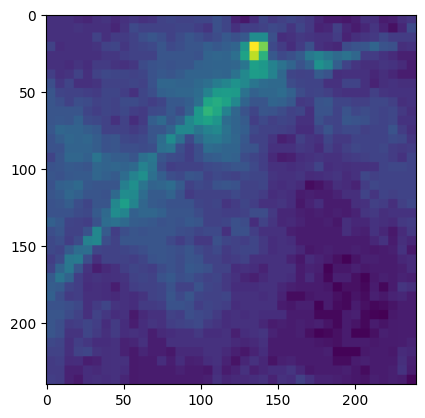

In [46]:
plt.imshow(img)

# Data Loader Pytorch

In [47]:
da = data["data"]

image_channels = [ch for ch in da.coords["channel"].values if ch != "labels"]

X_da = da.sel(channel=image_channels)
Y_da = da.sel(channel="labels")

In [48]:
X_da

<xarray.DataArray 'data' (sample: 2803, channel: 11, x: 240, y: 240)> Size: 7GB
[1775980800 values with dtype=float32]
Coordinates:
  * sample   (sample) int16 6kB 0 1 2 3 4 5 6 ... 2797 2798 2799 2800 2801 2802
  * channel  (channel) <U6 264B '442nm' '492nm' '559nm' ... '1610nm' '2186nm'
  * x        (x) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239
  * y        (y) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239

In [49]:
print(X_da.shape)
print(Y_da.shape)
print(X_da.dims)
print(Y_da.dims)

(2803, 11, 240, 240)
(2803, 240, 240)
('sample', 'channel', 'x', 'y')
('sample', 'x', 'y')


In [50]:
import torch
from torch.utils.data import Dataset

class XarraySegmentationDataset(Dataset):
    def __init__(self, xarray_data, label_channel="labels", transform=None, target_transform=None):
        """
        xarray_data: xarray.DataArray with dims (sample, channel, x, y)
        label_channel: name of the label channel
        transform: optional transform for input image
        target_transform: optional transform for label
        """
        self.da = xarray_data
        self.label_channel = label_channel
        self.transform = transform
        self.target_transform = target_transform

        self.image_channels = [ch for ch in self.da.coords["channel"].values if ch != label_channel]

    def __len__(self):
        return self.da.sizes["sample"]

    def __getitem__(self, idx):
        # Select one sample
        sample = self.da.isel(sample=idx)

        # Inputs: all channels except label
        x = sample.sel(channel=self.image_channels).values  # shape: (C, H, W)

        # Target: label channel
        y = sample.sel(channel=self.label_channel).values   # shape: (H, W)

        # Convert to torch tensors
        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.long)

        if self.transform is not None:
            x = self.transform(x)

        if self.target_transform is not None:
            y = self.target_transform(y)

        return x, y

In [51]:
dataset = XarraySegmentationDataset(da)

print(len(dataset))

x, y = dataset[0]
print(x.shape)   # expected: [11, 240, 240]
print(y.shape)   # expected: [240, 240]
print(x.dtype)   # float32
print(y.dtype)   # long

2803
torch.Size([11, 240, 240])
torch.Size([240, 240])
torch.float32
torch.int64


In [52]:
from torch.utils.data import DataLoader

loader = DataLoader(dataset, batch_size=8, shuffle=True)

batch_x, batch_y = next(iter(loader))

print(batch_x.shape)  # [8, 11, 240, 240]
print(batch_y.shape)  # [8, 240, 240]

torch.Size([8, 11, 240, 240])
torch.Size([8, 240, 240])


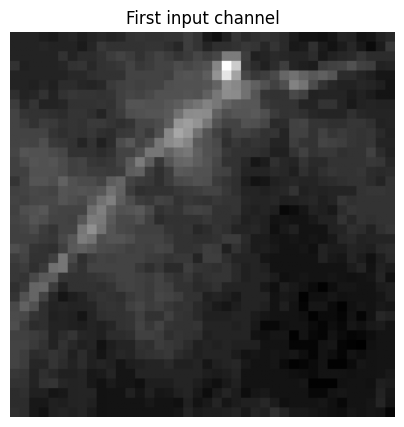

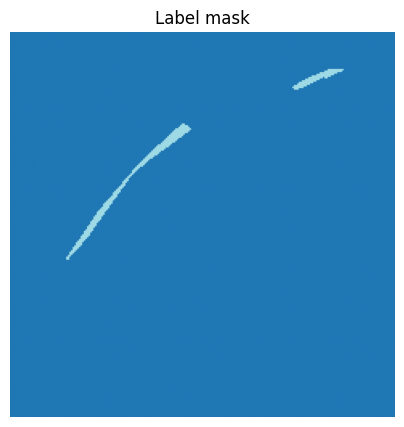

In [53]:
import matplotlib.pyplot as plt

x, y = dataset[0]

plt.figure(figsize=(5, 5))
plt.imshow(x[0].numpy(), cmap="gray")
plt.title("First input channel")
plt.axis("off")
plt.show()

plt.figure(figsize=(5, 5))
plt.imshow(y.numpy(), cmap="tab20")
plt.title("Label mask")
plt.axis("off")
plt.show()